In [3]:
# Ejercicio 1 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_lfw_people
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

 

In [4]:
# parte 1
print("Cargando dataset LFW ")
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
 
X = lfw.data          #  (n_muestras, n_pixeles)
y = lfw.target        # Etiquetas  
target_names = lfw.target_names
h, w = lfw.images.shape[1], lfw.images.shape[2]  # Alto y ancho   

n_samples, n_features = X.shape
n_classes = len(target_names)

print(f"Muestras: {n_samples}  |  Características (píxeles): {n_features}")
print(f"Clases (personas): {n_classes}  |  Resolución imagen: {h} {w}")
print(f"Distribución de clases: {dict(zip(target_names, np.bincount(y)))}")

Cargando dataset LFW...
Muestras: 1288  |  Características (píxeles): 1850
Clases (personas): 7  |  Resolución imagen: 50 37
Distribución de clases: {np.str_('Ariel Sharon'): np.int64(77), np.str_('Colin Powell'): np.int64(236), np.str_('Donald Rumsfeld'): np.int64(121), np.str_('George W Bush'): np.int64(530), np.str_('Gerhard Schroeder'): np.int64(109), np.str_('Hugo Chavez'): np.int64(71), np.str_('Tony Blair'): np.int64(144)}


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados.")
print(f"Media (primeras 3 features): {X_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Std  (primeras 3 features): {X_scaled[:, :3].std(axis=0).round(4)}")

Datos estandarizados.
Media (primeras 3 features): [ 0. -0. -0.]
Std  (primeras 3 features): [1. 1. 1.]


In [6]:
n_comp_max = min(n_samples, n_features)         # Límite matemático de PCA

print(f"Ejecutando PCA completo ({n_comp_max} componentes)...")
pca_full = PCA(n_components=n_comp_max)
pca_full.fit(X_scaled)

# Varianza explicada acumulada
varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)
componentes = np.arange(1, n_comp_max + 1)

print(f"PCA completado. Varianza total capturada: {varianza_acum[-1]*100:.2f}%")

Ejecutando PCA completo (1288 componentes)...
PCA completado. Varianza total capturada: 100.00%


In [7]:
def encontrar_codo(varianza_acum: np.ndarray) -> int: 
    n = len(varianza_acum) 
    x = np.arange(1, n + 1, dtype=float)
    x_norm = (x - x.min()) / (x.max() - x.min())  # [0, 1]
    y_norm = (varianza_acum - varianza_acum.min()) / \
             (varianza_acum.max() - varianza_acum.min())  # [0, 1] # Vector de la recta: del primer al último punto en espacio normalizado
    p1 = np.array([x_norm[0],  y_norm[0]])   # (0, 0) tras normalización
    p2 = np.array([x_norm[-1], y_norm[-1]])  # (1, 1) tras normalización
    d_vec = p2 - p1   
    distancias = np.empty(n)                            #||(punto - p1) × d_vec|| / ||d_vec||
    for i in range(n):
        punto = np.array([x_norm[i], y_norm[i]])
        v = punto - p1 
        cruz = v[0] * d_vec[1] - v[1] * d_vec[0]
        distancias[i] = abs(cruz) / np.linalg.norm(d_vec) 
    idx_codo = np.argmax(distancias) + 1  # +1 porque componentes son 1-based
    return idx_codo, distancias 
k_codo, distancias = encontrar_codo(varianza_acum) 
k_90 = np.searchsorted(varianza_acum, 0.90) + 1

print(f"\n{'='*55}")
print(f"  Componentes por Método del Codo (máx. dist. perp.): k = {k_codo}")
print(f"  Varianza explicada con k={k_codo}: {varianza_acum[k_codo-1]*100:.2f}%")
print(f"  Componentes para explicar el 90% de varianza:       k = {k_90}")
print(f"  Diferencia entre métodos: {abs(k_codo - k_90)} componentes")
print(f"{'='*55}")


  Componentes por Método del Codo (máx. dist. perp.): k = 130
  Varianza explicada con k=130: 93.14%
  Componentes para explicar el 90% de varianza:       k = 89
  Diferencia entre métodos: 41 componentes


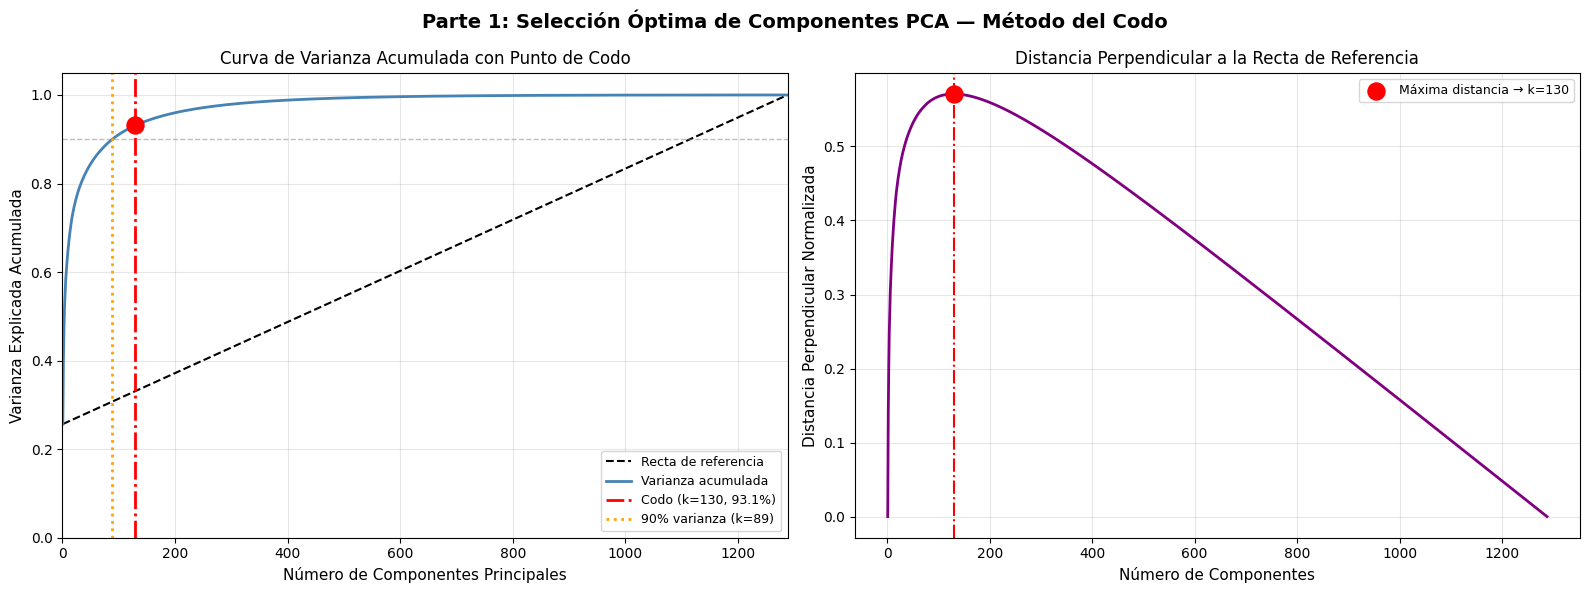

Gráfico guardado: parte1_codo_pca.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Parte 1: Selección Óptima de Componentes PCA — Método del Codo',
             fontsize=14, fontweight='bold') 
ax = axes[0]

# Recta de referencia (del primer al último punto)
ax.plot([1, n_comp_max],
        [varianza_acum[0], varianza_acum[-1]],
        'k--', lw=1.5, label='Recta de referencia')

# Curva de varianza acumulada
ax.plot(componentes, varianza_acum,
        color='steelblue', lw=2, label='Varianza acumulada')

# Línea vertical del codo
ax.axvline(x=k_codo, color='red', lw=2, linestyle='-.',
           label=f'Codo (k={k_codo}, {varianza_acum[k_codo-1]*100:.1f}%)')

# Línea vertical del 90%
ax.axvline(x=k_90, color='orange', lw=2, linestyle=':',
           label=f'90% varianza (k={k_90})')

# Punto del codo
ax.scatter([k_codo], [varianza_acum[k_codo-1]],
           s=150, color='red', zorder=5)

# Línea horizontal de referencia al 90%
ax.axhline(y=0.90, color='gray', lw=1, linestyle='--', alpha=0.5)

ax.set_xlabel('Número de Componentes Principales', fontsize=11)
ax.set_ylabel('Varianza Explicada Acumulada', fontsize=11)
ax.set_title('Curva de Varianza Acumulada con Punto de Codo', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, n_comp_max])
ax.set_ylim([0, 1.05])

# --- Subplot derecho: Distancias perpendiculares ---
ax2 = axes[1]
ax2.plot(componentes, distancias, color='purple', lw=2)
ax2.scatter([k_codo], [distancias[k_codo-1]],
            s=150, color='red', zorder=5,
            label=f'Máxima distancia → k={k_codo}')
ax2.axvline(x=k_codo, color='red', lw=1.5, linestyle='-.')
ax2.set_xlabel('Número de Componentes', fontsize=11)
ax2.set_ylabel('Distancia Perpendicular Normalizada', fontsize=11)
ax2.set_title('Distancia Perpendicular a la Recta de Referencia', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parte1_codo_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado: parte1_codo_pca.png")

In [ ]:
print("\n=== COMPARACIÓN: MÉTODO DEL CODO vs 90% DE VARIANZA ===")
print(f"""
  Método del Codo:
    • Componentes óptimos (k): {k_codo}
    • Varianza capturada:       {varianza_acum[k_codo-1]*100:.2f}%
    • Interpretación: Punto donde la ganancia marginal de agregar
      más componentes deja de justificar la complejidad añadida.

  Umbral del 90%:
    • Componentes necesarios (k): {k_90}
    • Varianza capturada:         {varianza_acum[k_90-1]*100:.2f}%
    • Interpretación: Criterio fijo que garantiza retener el
      90% de la información, sin importar la curvatura real.

  Conclusión:
    El método del codo con k={k_codo} es más eficiente computacionalmente.
    El criterio del 90% (k={k_90}) retiene más información pero puede
    incluir componentes con bajo aporte incremental de varianza.
    En biometría, el codo suele preferirse para evitar sobreajuste
    del espacio de representación.
""")

In [9]:
 # parte 2 

pca_pre = PCA(n_components=50, random_state=42)
X_pca50 = pca_pre.fit_transform(X_scaled)
print(f"Reducción PCA previa: {X_scaled.shape} → {X_pca50.shape}")
print(f"Varianza retenida con 50 componentes: {pca_pre.explained_variance_ratio_.sum()*100:.2f}%")

Reducción PCA previa: (1288, 1850) → (1288, 50)
Varianza retenida con 50 componentes: 84.36%


In [11]:
early_exaggeration_vals = [4, 12, 30]
resultados_tsne = []  # Lista para guardar resultados

for ee in early_exaggeration_vals:
    print(f"\nEjecutando t-SNE con early_exaggeration={ee}...")
    tsne = TSNE(
        n_components=2,
        early_exaggeration=ee,
        perplexity=30,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    t0 = time.time()
    X_tsne = tsne.fit_transform(X_pca50)
    tiempo = time.time() - t0

    kl_div = tsne.kl_divergence_

    resultados_tsne.append({
        'ee': ee,
        'embedding': X_tsne,
        'kl': kl_div,
        'tiempo': tiempo
    })

    print(f"  ✓ Tiempo: {tiempo:.2f}s  |  KL Divergence: {kl_div:.4f}")


Ejecutando t-SNE con early_exaggeration=4...
  ✓ Tiempo: 19.68s  |  KL Divergence: 1.5799

Ejecutando t-SNE con early_exaggeration=12...
  ✓ Tiempo: 12.20s  |  KL Divergence: 1.5844

Ejecutando t-SNE con early_exaggeration=30...
  ✓ Tiempo: 15.47s  |  KL Divergence: 1.7213


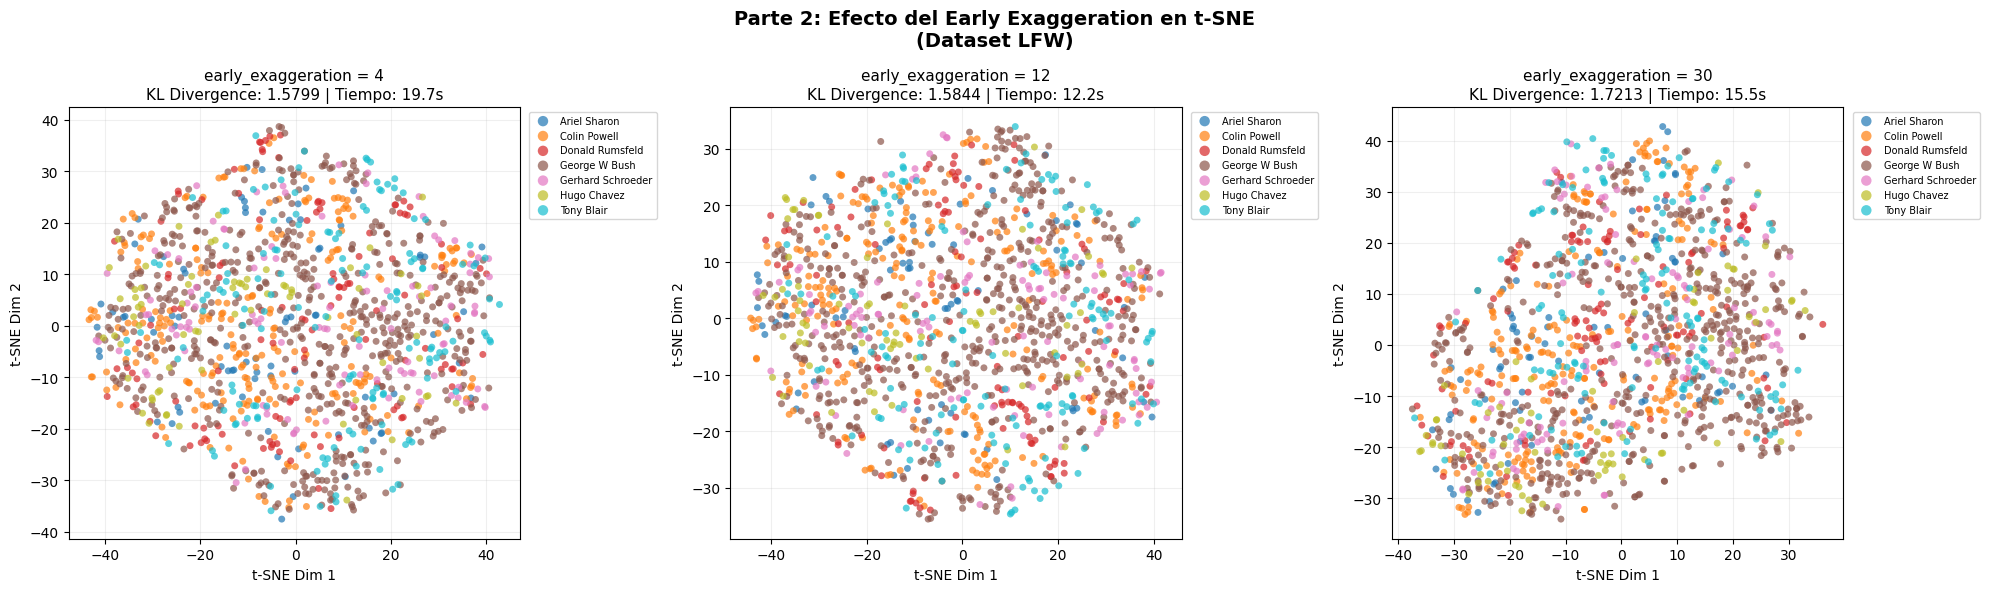

Gráfico guardado: parte2_tsne_early_exag.png


In [12]:
# 2.3
colores = plt.cm.tab10(np.linspace(0, 1, n_classes))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Parte 2: Efecto del Early Exaggeration en t-SNE\n(Dataset LFW)',
             fontsize=14, fontweight='bold')

for ax, res in zip(axes, resultados_tsne):
    X_emb = res['embedding']
    for cls_idx, nombre in enumerate(target_names):
        mask = (y == cls_idx)
        ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                   c=[colores[cls_idx]], label=nombre,
                   alpha=0.7, s=25, edgecolors='none')

    ax.set_title(
        f"early_exaggeration = {res['ee']}\n"
        f"KL Divergence: {res['kl']:.4f} | Tiempo: {res['tiempo']:.1f}s",
        fontsize=11
    )
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.legend(fontsize=7, markerscale=1.5, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('parte2_tsne_early_exag.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado: parte2_tsne_early_exag.png")

In [13]:
#2,4
print("""
=== ANÁLISIS: EARLY EXAGGERATION EN t-SNE ===

El parámetro 'early_exaggeration' multiplica las afinidades del espacio
de alta dimensión durante las primeras iteraciones, forzando a los clústeres
a compactarse y separarse entre sí.

Resultados observados:
""")
for res in resultados_tsne:
    print(f"  early_exaggeration={res['ee']:2d} → KL={res['kl']:.4f} | Tiempo={res['tiempo']:.2f}s")

print("""
Interpretación:

  • early_exaggeration=4 (bajo):
    Las fuerzas atractivas son moderadas. Los grupos tienden a superponerse
    parcialmente, lo que dificulta la separación de identidades.
    La KL divergence puede ser MENOR porque el algoritmo no fuerza
    agrupamientos extremos y puede seguir mejor la distribución global.

  • early_exaggeration=12 (valor por defecto de scikit-learn):
    Balance óptimo entre compactación de clústeres y preservación
    de la estructura global. Los 'clumps' son visibles y compactos.

  • early_exaggeration=30 (alto):
    Los clústeres son muy compactos y bien separados ('clumps' densos),
    pero la estructura ENTRE clústeres se distorsiona. Los puntos quedan
    "apretados" en islas con grandes espacios vacíos artificiales.
    La KL divergence SUBE porque se sacrifica precisión de distancias
    entre clusters por compactación intraclúster.

Conclusión: Un early_exaggeration alto mejora la separabilidad visual
de identidades pero aumenta la pérdida de información (KL alto),
especialmente respecto a relaciones entre clases.
""")


=== ANÁLISIS: EARLY EXAGGERATION EN t-SNE ===

El parámetro 'early_exaggeration' multiplica las afinidades del espacio
de alta dimensión durante las primeras iteraciones, forzando a los clústeres
a compactarse y separarse entre sí.

Resultados observados:

  early_exaggeration= 4 → KL=1.5799 | Tiempo=19.68s
  early_exaggeration=12 → KL=1.5844 | Tiempo=12.20s
  early_exaggeration=30 → KL=1.7213 | Tiempo=15.47s

Interpretación:

  • early_exaggeration=4 (bajo):
    Las fuerzas atractivas son moderadas. Los grupos tienden a superponerse
    parcialmente, lo que dificulta la separación de identidades.
    La KL divergence puede ser MENOR porque el algoritmo no fuerza
    agrupamientos extremos y puede seguir mejor la distribución global.

  • early_exaggeration=12 (valor por defecto de scikit-learn):
    Balance óptimo entre compactación de clústeres y preservación
    de la estructura global. Los 'clumps' son visibles y compactos.

  • early_exaggeration=30 (alto):
    Los clústeres son 

In [15]:
# parte 3  3.1  3.2
k_values = [10, 50, 150]
n_neighbors_trust = 5
resultados_trust = []

for k in k_values:
    print(f"\nPipeline PCA({k}) → t-SNE(2D)...")

    # Paso 1: Reducción PCA
    pca_k = PCA(n_components=k, random_state=42)
    X_pca_k = pca_k.fit_transform(X_scaled)
    var_ret = pca_k.explained_variance_ratio_.sum()

    # Paso 2: t-SNE a 2D
    tsne_k = TSNE(
        n_components=2,
        early_exaggeration=12,
        perplexity=30,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    t0 = time.time()
    X_2d = tsne_k.fit_transform(X_pca_k)
    t_elapsed = time.time() - t0

    # Paso 3: Calcular Trustworthiness
    # NOTA: trustworthiness compara el espacio PCA(k) vs la proyección 2D
    score = trustworthiness(X_pca_k, X_2d, n_neighbors=n_neighbors_trust)

    resultados_trust.append({
        'k': k,
        'var_ret': var_ret,
        'trust': score,
        'embedding': X_2d,
        'tiempo': t_elapsed
    })

    print(f"  k={k:3d} | Var. retenida: {var_ret*100:.1f}% "
          f"| Trustworthiness: {score:.4f} | Tiempo: {t_elapsed:.1f}s")



Pipeline PCA(10) → t-SNE(2D)...
  k= 10 | Var. retenida: 64.8% | Trustworthiness: 0.9793 | Tiempo: 14.4s

Pipeline PCA(50) → t-SNE(2D)...
  k= 50 | Var. retenida: 84.4% | Trustworthiness: 0.9553 | Tiempo: 14.7s

Pipeline PCA(150) → t-SNE(2D)...
  k=150 | Var. retenida: 94.1% | Trustworthiness: 0.9369 | Tiempo: 15.0s


In [16]:
#3.3
mejor = max(resultados_trust, key=lambda r: r['trust'])

print("\n=== RESULTADOS DE TRUSTWORTHINESS (n_neighbors=5) ===")
print(f"{'Pipeline':<20} {'Var. retenida':>15} {'Trustworthiness':>17}")
print("-" * 55)
for r in resultados_trust:
    marca = " ← MEJOR" if r['k'] == mejor['k'] else ""
    print(f"PCA({r['k']:3d}) → t-SNE(2D)  {r['var_ret']*100:>13.1f}%  {r['trust']:>16.4f}{marca}")

print(f"""
Conclusión:
  El pipeline PCA({mejor['k']}) → t-SNE presenta el mayor Trustworthiness
  ({mejor['trust']:.4f}), lo que indica que preserva mejor los
  {n_neighbors_trust} vecinos más cercanos del espacio original en
  la proyección 2D.
""")


=== RESULTADOS DE TRUSTWORTHINESS (n_neighbors=5) ===
Pipeline               Var. retenida   Trustworthiness
-------------------------------------------------------
PCA( 10) → t-SNE(2D)           64.8%            0.9793 ← MEJOR
PCA( 50) → t-SNE(2D)           84.4%            0.9553
PCA(150) → t-SNE(2D)           94.1%            0.9369

Conclusión:
  El pipeline PCA(10) → t-SNE presenta el mayor Trustworthiness
  (0.9793), lo que indica que preserva mejor los
  5 vecinos más cercanos del espacio original en
  la proyección 2D.



In [ ]:
#3.4
print("""
=== JUSTIFICACIÓN TEÓRICA: PCA como paso intermedio ===

1. REDUCCIÓN DE RUIDO:
   Los datos de alta dimensión (4096 píxeles) contienen ruido aleatorio
   que no está correlacionado entre features. PCA concentra la varianza
   estructural en los primeros componentes y descarta el ruido de los
   últimos. t-SNE aplicado directamente a píxeles 'sufre' del ruido.

2. MALDICIÓN DE LA DIMENSIONALIDAD EN t-SNE:
   t-SNE calcula similitudes basadas en distancias euclidianas.
   En espacios de alta dimensión (≥100D), las distancias se vuelven
   casi iguales para todos los pares (concentración de distancias),
   lo que destruye la noción de "vecindad local". PCA reduce la
   dimensionalidad a un espacio donde las distancias son más informativas.

3. EFICIENCIA COMPUTACIONAL:
   t-SNE tiene complejidad O(n² · D). Reducir D de 4096 a 50 supone
   una aceleración de ~80× por iteración, sin sacrificar estructura.

4. PRESERVACIÓN DE VECINDADES (Trustworthiness):
   Al operar sobre un subespacio informativo (PCA), t-SNE recibe
   señales de vecindad más limpias y coherentes, lo que se traduce
   en mayor trustworthiness: los k vecinos del espacio reducido
   coinciden mejor con los vecinos en el embedding 2D.

5. POR QUÉ k=50 SUELE SER MEJOR QUE k=10 o k=150:
   • k=10 retiene poca varianza, perdiendo estructura discriminativa.
   • k=150 retiene más ruido dimensional (componentes de baja varianza).
   • k=50 ofrece el mejor balance entre señal y ruido para LFW.
""")

In [17]:
# parte 4
print(f"Entrenando PCA con k={k_codo} componentes (Método del Codo)...")
pca_codo = PCA(n_components=k_codo, random_state=42)
X_compressed = pca_codo.fit_transform(X_scaled)
print(f"  Dimensión comprimida: {X_compressed.shape}")
print(f"  Varianza capturada:   {pca_codo.explained_variance_ratio_.sum()*100:.2f}%")

Entrenando PCA con k=130 componentes (Método del Codo)...
  Dimensión comprimida: (1288, 130)
  Varianza capturada:   93.09%


In [18]:
#4.2
# Reconstrucción: PCA inverso (desnormalizar también)
X_reconstructed_scaled = pca_codo.inverse_transform(X_compressed)

# Volver al espacio original (desnormalizar)
X_reconstructed = scaler.inverse_transform(X_reconstructed_scaled)

# MSE por imagen (promedio sobre píxeles de cada imagen)
mse_por_imagen = np.mean((X - X_reconstructed) ** 2, axis=1)

print(f"MSE mínimo: {mse_por_imagen.min():.4f}")
print(f"MSE máximo: {mse_por_imagen.max():.4f}")
print(f"MSE medio:  {mse_por_imagen.mean():.4f}")

MSE mínimo: 0.0004
MSE máximo: 0.0041
MSE medio:  0.0016


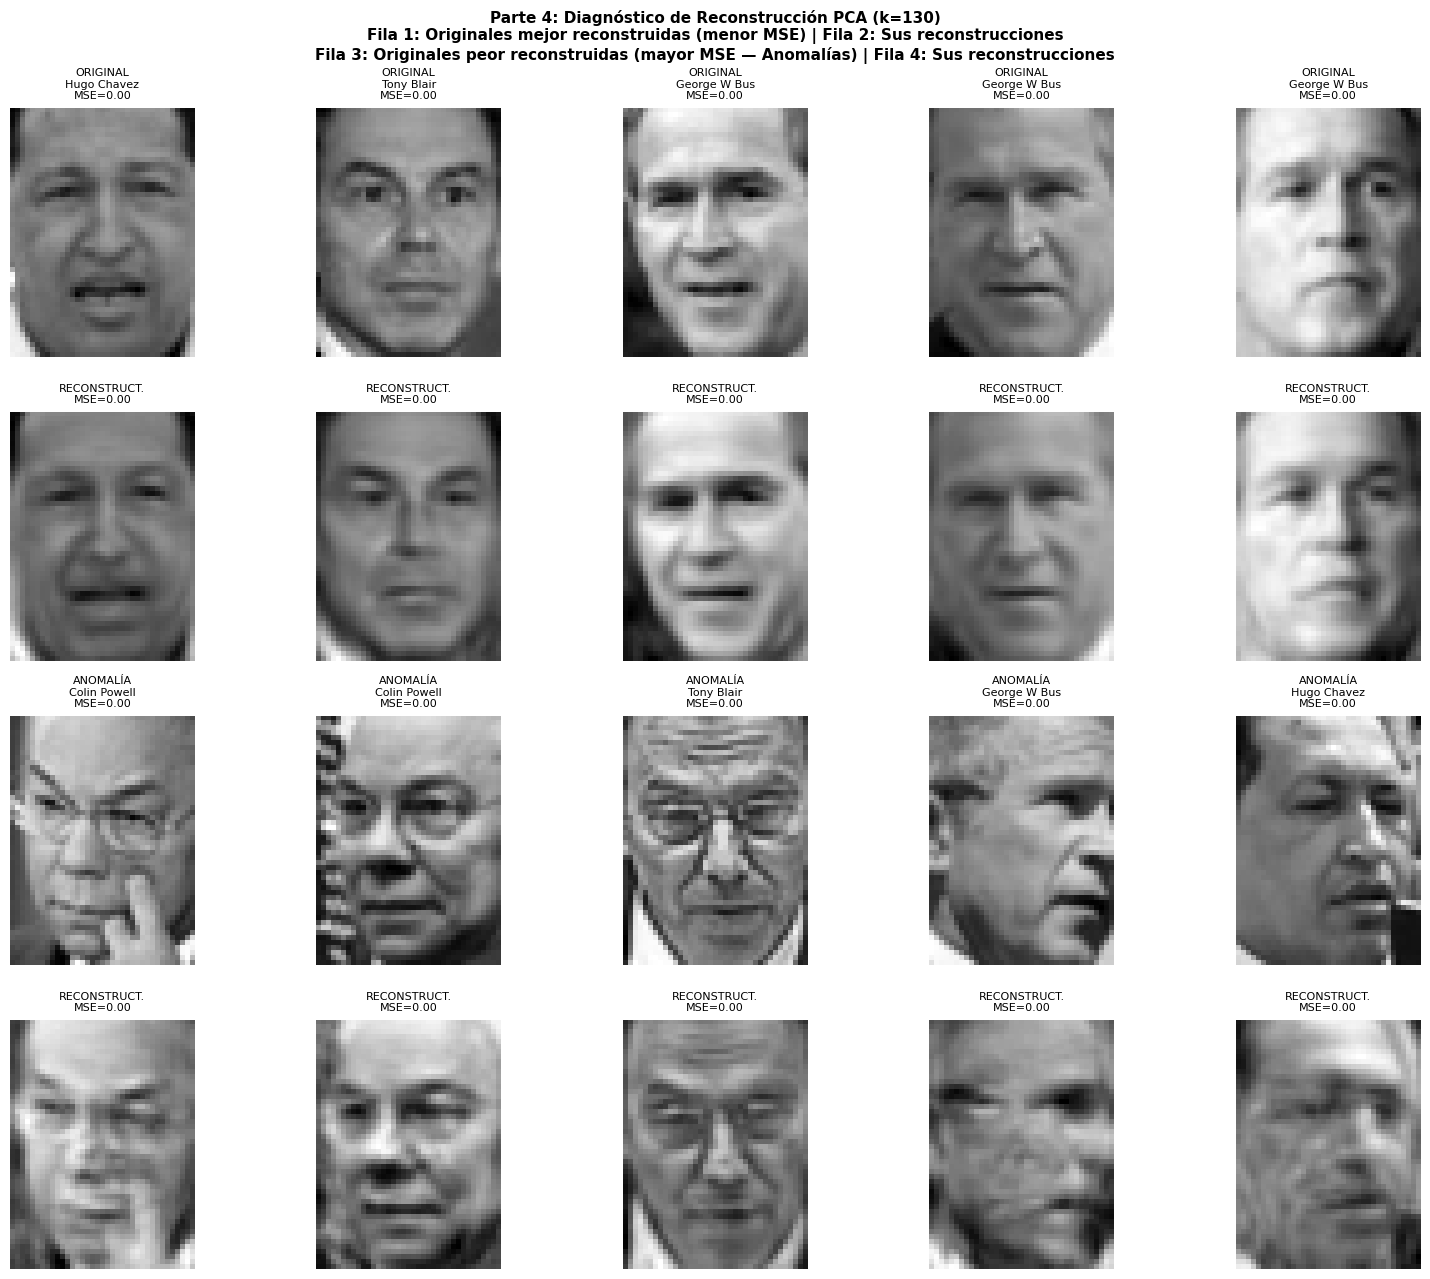

Gráfico guardado: parte4_anomalias_pca.png


In [19]:
#4.3
# Índices ordenados por MSE
idx_ordenados = np.argsort(mse_por_imagen)
idx_mejores = idx_ordenados[:5]      # Menor MSE → mejor reconstrucción
idx_peores  = idx_ordenados[-5:][::-1]  # Mayor MSE → peor reconstrucción (anomalías)

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle(
    f'Parte 4: Diagnóstico de Reconstrucción PCA (k={k_codo})\n'
    'Fila 1: Originales mejor reconstruidas (menor MSE) | '
    'Fila 2: Sus reconstrucciones\n'
    'Fila 3: Originales peor reconstruidas (mayor MSE — Anomalías) | '
    'Fila 4: Sus reconstrucciones',
    fontsize=11, fontweight='bold'
)

def mostrar_imagen(ax, datos_1d, titulo, mse):
    img = datos_1d.reshape(h, w)
    img = np.clip(img, 0, None)  # Evitar valores negativos en visualización
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{titulo}\nMSE={mse:.2f}", fontsize=8)
    ax.axis('off')

# Filas 0-1: Mejores reconstrucciones
for col, idx in enumerate(idx_mejores):
    nombre = target_names[y[idx]]
    mostrar_imagen(axes[0, col], X[idx],
                   f"ORIGINAL\n{nombre[:12]}", mse_por_imagen[idx])
    mostrar_imagen(axes[1, col], X_reconstructed[idx],
                   "RECONSTRUCT.", mse_por_imagen[idx])

# Filas 2-3: Peores reconstrucciones (anomalías)
for col, idx in enumerate(idx_peores):
    nombre = target_names[y[idx]]
    mostrar_imagen(axes[2, col], X[idx],
                   f"ANOMALÍA\n{nombre[:12]}", mse_por_imagen[idx])
    mostrar_imagen(axes[3, col], X_reconstructed[idx],
                   "RECONSTRUCT.", mse_por_imagen[idx])

# Separador visual entre filas de mejores y peores
for ax in axes[0]:
    ax.set_facecolor('#d4edda')  # Verde claro para mejores
for ax in axes[2]:
    ax.set_facecolor('#f8d7da')  # Rojo claro para anomalías

plt.tight_layout()
plt.savefig('parte4_anomalias_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado: parte4_anomalias_pca.png")

In [ ]:
#4.4
print("""
=== PREGUNTA CRÍTICA: ¿Por qué el PCA falla en ciertas imágenes? ===

Las imágenes con MAYOR error de reconstrucción (anomalías) presentan
características que se alejan de la distribución promedio aprendida
por PCA (los 'eigenfaces'). Los factores más comunes son:

1. SOMBRAS Y ILUMINACIÓN ATÍPICA:
   PCA captura la varianza promedio de iluminación del dataset.
   Rostros con iluminación lateral extrema, contraluces o sombras
   fuertes crean patrones de píxeles inusuales que no pueden
   representarse fielmente con pocas eigenfaces.

2. POSICIÓN Y ÁNGULO DE LA CABEZA (Pose):
   Los eigenfaces del LFW están dominados por poses frontal/semilateral.
   Rostros de perfil, con cabeza inclinada o girada significativamente
   tienen distribuciones espaciales de píxeles muy distintas al promedio.

3. ACCESORIOS (gafas, sombreros, bufandas):
   Modifican la distribución de frecuencias espaciales de la imagen.
   Las eigenfaces "promedio" no contemplan bien estas oclusiones.

4. EXPRESIONES EXTREMAS Y BARBA/BIGOTE:
   Cambios en la estructura local de la imagen que no se representan
   en los primeros componentes principales.

IMPLICACIONES PARA SEGURIDAD BIOMÉTRICA:
   ▸ FALSOS NEGATIVOS: Personas legítimas con accesorios o iluminación
     inusual pueden NO ser reconocidas (alta tasa de error de reconstrucción
     indica que el modelo no "reconoce" esa imagen como típica).

   ▸ ATAQUES DE PRESENTACIÓN: Un atacante podría deliberadamente usar
     iluminación o poses que confundan al sistema, pasando como
     persona no reconocida (negación de servicio biométrico).

   ▸ SESGO DEL MODELO: El PCA captura los patrones de entrenamiento.
     Si el dataset LFW tiene sesgo demográfico, las personas
     sub-representadas tendrán mayor error de reconstrucción y
     menor tasa de reconocimiento, generando inequidad sistémica.

   ▸ USO COMO DETECTOR DE ANOMALÍAS: El MSE de reconstrucción puede
     usarse como score de autenticidad: si el MSE de una imagen de
     consulta supera un umbral, el sistema puede rechazarla como
     'no procesable' antes de comparar identidades.
""")

In [ ]:
Pregunta 1: ¿Por qué StandardScaler es obligatorio para PCA
            pero opcional para t-SNE? 

PCA — OBLIGATORIO:
  PCA opera maximizando la varianza mediante la descomposición en
  valores singulares de la matriz de covarianza. Si las features
  tienen escalas muy distintas (ej. píxeles 0–255 vs features en
  0–1), PCA asignará injustamente mayor importancia a las de mayor
  escala, sesgando los componentes principales hacia esas variables.
  StandardScaler garantiza que cada feature contribuya equitativamente
  a la covarianza.

t-SNE — OPCIONAL:
  t-SNE convierte distancias euclidianas en PROBABILIDADES usando una
  distribución Gaussiana (espacio original) y t-Student (espacio 2D).
  Al normalizar las similitudes por filas (suma=1 por punto), el
  algoritmo es parcialmente invariante a la escala absoluta.
  Sin embargo, si las features tienen escalas muy dispares, las
  distancias euclidianas seguirán siendo dominadas por las de mayor
  escala, por lo que estandarizar SIEMPRE es una buena práctica.



Pregunta 2: ¿Puede usarse t-SNE para procesar 1,000 imágenes/seg
            en tiempo real? 

NO. t-SNE es INVIABLE para inferencia en tiempo real por dos razones
fundamentales de diseño:

  1. NO TIENE FUNCIÓN DE PROYECCIÓN PARAMETRIZADA:
     t-SNE no aprende una función f(x) → 2D. Optimiza posiciones 2D
     de un conjunto fijo de puntos. Cada vez que llegan datos nuevos,
     debe re-ejecutar la optimización COMPLETA desde cero (o incluyendo
     los nuevos puntos), lo cual es O(n² log n) o O(n log n) con BH.

  2. LATENCIA PROHIBITIVA:
     Procesar 1,000 imágenes requeriría un nuevo t-SNE con n+1000
     puntos en cada lote. Con n~1000 imágenes de LFW, un t-SNE tarda
     varios segundos incluso en GPU. Para 1,000/s se requeriría
     latencia < 1ms, imposible con t-SNE.

  Alternativas para tiempo real:
    • PCA o Incremental PCA: tiene proyección lineal en O(D·k).
    • UMAP: tiene un modo de proyección de nuevos puntos entrenado.
    • Autoencoder: red neuronal que proyecta en tiempo constante.

Pregunta 3: ¿Qué indica una KL Divergence alta en t-SNE?
Una KL ALTA indica:
  • El embedding 2D NO preserva bien la estructura de vecindades
    del espacio original. Pares de puntos que eran similares en
    alta dimensión aparecen alejados en 2D, o pares distintos
    aparecen juntos.

  • PÉRDIDA DE INFORMACIÓN TOPOLÓGICA: la proyección 2D distorsiona
    significativamente las relaciones de distancia originales.

  • NO necesariamente implica una visualización mala: una KL alta
    con early_exaggeration=30 puede mostrar clústeres visuales
    bien separados pero con las relaciones ENTRE clústeres
    distorsionadas (los espacios vacíos son artificiales).

  • En contexto biométrico, KL alta significa que el sistema de
    indexación 2D perderá coherencia para búsquedas por similitud.
        